#  pytorch로 CNN 모델링하기

## 1.환경준비

### (1) 라이브러리 로딩

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [11]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchsummary import summary

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

### (2) 데이터로딩

In [4]:
train_dataset = datasets.MNIST(root="data", train=True, download=True, transform=ToTensor() )
test_dataset = datasets.MNIST(root="data", train=False, download=True, transform=ToTensor() )

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:01<00:00, 5.98MB/s]


Extracting data\MNIST\raw\train-images-idx3-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 156kB/s]


Extracting data\MNIST\raw\train-labels-idx1-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.51MB/s]


Extracting data\MNIST\raw\t10k-images-idx3-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.27MB/s]

Extracting data\MNIST\raw\t10k-labels-idx1-ubyte.gz to data\MNIST\raw



## 2.데이터 준비

### (1) 학습 데이터 로더

In [5]:
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [6]:
for x, y in train_loader:
    print(f"Shape of X [N, C, H, W]: {x.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([128, 1, 28, 28])
Shape of y: torch.Size([128]) torch.int64


### (2) 검증/테스트 데이터셋

In [7]:
# test_dataset을 5000건씩 val : test로 분할
x_val, x_test = test_dataset.data[:5000], test_dataset.data[5000:]
y_val, y_test = test_dataset.targets[:5000], test_dataset.targets[5000:]

# 스케일링
x_val = x_val / 255
x_test = x_test/ 255

# 차원 맞추기
print(x_val.shape, x_test.shape)
x_val = x_val.view(5000, 1, 28, 28)
x_test = x_test.view(5000, 1, 28, 28)
print(x_val.shape, x_test.shape)

torch.Size([5000, 28, 28]) torch.Size([5000, 28, 28])
torch.Size([5000, 1, 28, 28]) torch.Size([5000, 1, 28, 28])


## 3.CNN 모델링1

### (1) 모델 설계

In [ ]:
model = nn.Sequential(
                    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
                    nn.ReLU(),
                    nn.MaxPool2d(kernel_size=2, stride=2),
                    nn.Flatten(),
                    nn.Linear(32*14*14, 10)
).to(device)

loss_fn = nn.CrossEntropyLoss() # softmax 연산이 포함됨
optimizer = Adam(model.parameters(), lr=0.001)

In [13]:
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
           Flatten-4                 [-1, 6272]               0
            Linear-5                   [-1, 10]          62,730
Total params: 63,050
Trainable params: 63,050
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.48
Params size (MB): 0.24
Estimated Total Size (MB): 0.72
----------------------------------------------------------------


### (2) 학습

#### 1) 필요 함수 생성

* 학습 함수

In [14]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)                  # 전체 데이터셋의 크기
    num_batches = len(dataloader)                   # 배치 크기
    tr_loss = 0
    model.train()                                   # 훈련 모드로 설정
    for x, y in dataloader:     # batch 단위 로딩
        x, y = x.to(device), y.to(device)      # 디바이스 지정
        # Feed Forward(오차 순전파)
        pred = model(x)
        loss = loss_fn(pred, y)
        tr_loss += loss
        # Backpropagation(오차 역전파)
        loss.backward()             # 역전파를 통해 각 파라미터에 대한 손실 기울기 계산
        optimizer.step()            # 옵티마이저가 모델의 파라미터를 업데이트
        optimizer.zero_grad()     # 옵티마이저의 기울기 값 초기화.
    tr_loss /= num_batches          # 모든 배치에서의 loss 평균
    return tr_loss.item()

* 검증 함수

[참조] 위 함수와 동일

In [17]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                      # 모델을 평가 모드로 설정
    with torch.no_grad():           # 평가 과정에서 기울기를 계산하지 않도록 설정
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()    # 예측 값 pred와 실제 값 y 사이의 손실 계산
    return eval_loss, pred

#### 2) 학습

In [18]:
epochs = 10
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val, y_val, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.313074, val loss : 0.179615
Epoch 2, train loss : 0.105420, val loss : 0.112421
Epoch 3, train loss : 0.073467, val loss : 0.086622
Epoch 4, train loss : 0.058607, val loss : 0.077530
Epoch 5, train loss : 0.051248, val loss : 0.077956
Epoch 6, train loss : 0.044562, val loss : 0.072914
Epoch 7, train loss : 0.040346, val loss : 0.074248
Epoch 8, train loss : 0.036377, val loss : 0.070115
Epoch 9, train loss : 0.033302, val loss : 0.075103
Epoch 10, train loss : 0.029590, val loss : 0.071339


#### 3) 학습결과 그래프

* 함수 생성

In [19]:
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

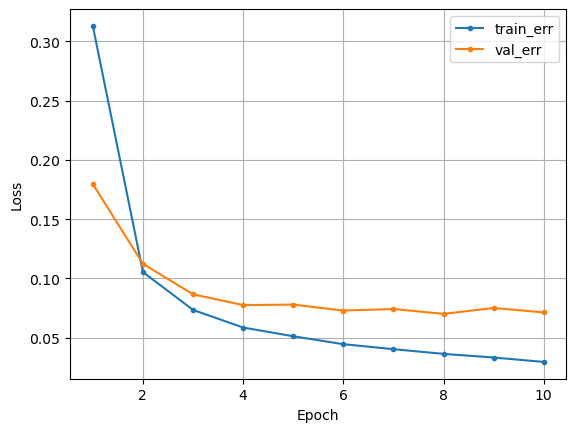

In [20]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (3) 예측 및 평가

In [21]:
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = pred.argmax(axis=1)

In [22]:
print(pred.device, y_test.device)
print(type(pred), type(y_test))

cuda:0 cpu
<class 'torch.Tensor'> <class 'torch.Tensor'>


In [23]:
# cpu, numpy로 변환
pred = pred.cpu().numpy()

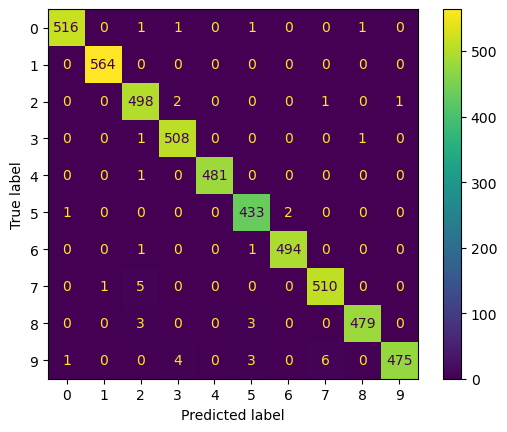

In [24]:
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [25]:
print(classification_report(y_test.numpy(), pred, digits = 4))

              precision    recall  f1-score   support

           0     0.9961    0.9923    0.9942       520
           1     0.9982    1.0000    0.9991       564
           2     0.9765    0.9920    0.9842       502
           3     0.9864    0.9961    0.9912       510
           4     1.0000    0.9979    0.9990       482
           5     0.9819    0.9931    0.9875       436
           6     0.9960    0.9960    0.9960       496
           7     0.9865    0.9884    0.9874       516
           8     0.9958    0.9876    0.9917       485
           9     0.9979    0.9714    0.9845       489

    accuracy                         0.9916      5000
   macro avg     0.9915    0.9915    0.9915      5000
weighted avg     0.9917    0.9916    0.9916      5000



## 4.CNN 모델링2

### (1) 모델 설계

In [26]:
model = nn.Sequential(
                    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
                    nn.ReLU(),
                    nn.MaxPool2d(kernel_size=2, stride=2),
                    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
                    nn.ReLU(),
                    nn.MaxPool2d(kernel_size=2, stride=2),
                    nn.Flatten(),
                    nn.Linear(64*7*7, 128),
                    nn.ReLU(),
                    nn.Linear(128, 10)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

In [27]:
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
              ReLU-5           [-1, 64, 14, 14]               0
         MaxPool2d-6             [-1, 64, 7, 7]               0
           Flatten-7                 [-1, 3136]               0
            Linear-8                  [-1, 128]         401,536
              ReLU-9                  [-1, 128]               0
           Linear-10                   [-1, 10]           1,290
Total params: 421,642
Trainable params: 421,642
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.67
Params size (MB): 1.61
Estimated T

### (2) 학습

In [35]:
epochs = 10
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val, y_val, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.077404, val loss : 0.069204
Epoch 2, train loss : 0.048081, val loss : 0.061358
Epoch 3, train loss : 0.034976, val loss : 0.048012
Epoch 4, train loss : 0.026749, val loss : 0.058196
Epoch 5, train loss : 0.020827, val loss : 0.044158
Epoch 6, train loss : 0.017764, val loss : 0.044582
Epoch 7, train loss : 0.015268, val loss : 0.058160
Epoch 8, train loss : 0.011754, val loss : 0.052324
Epoch 9, train loss : 0.009257, val loss : 0.060261
Epoch 10, train loss : 0.008938, val loss : 0.055475


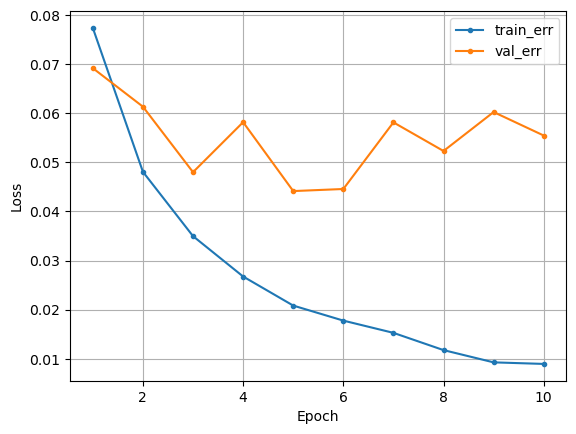

In [36]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (3) 예측 및 평가

In [31]:
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = pred.argmax(axis=1)

In [32]:
# cpu, numpy로 변환
pred = pred.cpu().numpy()

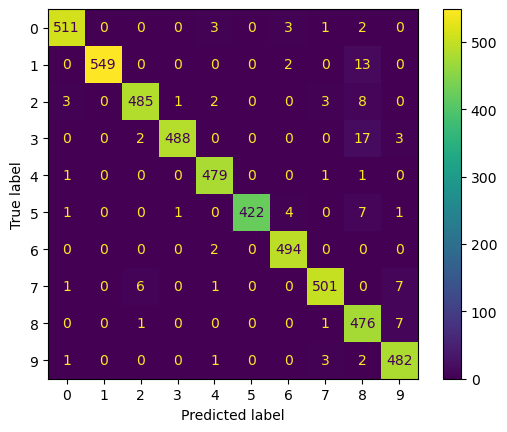

In [33]:
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [34]:
print(classification_report(y_test.numpy(), pred, digits = 4))

              precision    recall  f1-score   support

           0     0.9865    0.9827    0.9846       520
           1     1.0000    0.9734    0.9865       564
           2     0.9818    0.9661    0.9739       502
           3     0.9959    0.9569    0.9760       510
           4     0.9816    0.9938    0.9876       482
           5     1.0000    0.9679    0.9837       436
           6     0.9821    0.9960    0.9890       496
           7     0.9824    0.9709    0.9766       516
           8     0.9049    0.9814    0.9416       485
           9     0.9640    0.9857    0.9747       489

    accuracy                         0.9774      5000
   macro avg     0.9779    0.9775    0.9774      5000
weighted avg     0.9782    0.9774    0.9776      5000

